# Membrane Property GNN Training
Notebook to train a Heterogeneous GNN for predicting macroscopic properties directly from single CG MD snapshots.

In [10]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

# Add root project to python path
sys.path.append('../../')
from lipid_gnn.lipid_graph import MartiniHeteroGraphBuilder
from lipid_gnn.membrane_prop_gnn import MembranePropertyGNN
from lipid_gnn.functions_emil.functions import pkl_load

In [11]:
# =========================================
# Hyperparameters & Configuration
# =========================================
data_dir = '../../data/membrane_only'
results_dir = '../../results/properties'
ff_params_path = '../../resources/martini_ff_params.json'
ff_edge_params_path = '../../resources/martini_ff_edge_params.json'
ff_node_mapping_path = '../../resources/martini_ff_node_mapping.json'

# Target properties to predict. Easily add more from: 
# 'lipid_packing', 'thickness', 'thickness_std', 'compressibility', 'persistence', 'diffusivity'
property_label = 'lipid_packing'  # Top-level results directory
target_properties = ['lipid_packing']

# Train/Test Split
# test_size = 0.2 equals an 80/20 train/test split, which is a standard split ratio.
test_size = 0.2  

# Training Hyperparameters
batch_size = 2
epochs = 10
learning_rate = 5e-3

# Model Hyperparameters
in_channels = 4 # (mass, charge, sigma, epsilon)
hidden_dim = 64
num_layers = 3
spatial_cutoff = 11.0 # 1.1 nm in Angstroms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [12]:
# =========================================
# 1. Extract Graphs and Target Properties
# =========================================
graphs = []
compositions = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
print(f"Found {len(compositions)} membrane compositions.")

for comp in tqdm(compositions, desc="Building Graphs"):
    top_file = os.path.join(data_dir, comp, "run/prun.tpr")
    traj_file = os.path.join(data_dir, comp, "run/prun.xtc")
    prop_file = os.path.join(results_dir, f"{comp}.h5")
    
    if not (os.path.exists(top_file) and os.path.exists(traj_file) and os.path.exists(prop_file)):
        print(f"Missing data for {comp}, skipping.")
        continue
        
    # Build HeteroData for Frame 0 (meaning single static snapshot)
    builder = MartiniHeteroGraphBuilder(
        topology_file=top_file, 
        trajectory_file=traj_file, 
        spatial_cutoff=spatial_cutoff, 
        ff_params_path=ff_params_path,
        ff_edge_params_path=ff_edge_params_path,
        ff_node_mapping_path=ff_node_mapping_path
    )
    hetero_data = builder.process_frame(frame_idx=0)
    
    # Load continuous target property values
    try:
        mean_dict, raw_dict = pkl_load(prop_file)
        
        # Extract specific properties into a PyTorch array vector
        target_vec = []
        for prop in target_properties:
            target_vec.append(mean_dict[prop])
            
        hetero_data.y = torch.tensor([target_vec], dtype=torch.float)
        graphs.append(hetero_data)
    except Exception as e:
        print(f"Error loading properties for {comp}: {e}")

    print(f"Successfully loaded {len(graphs)} graphs.")

# Extensible target Z-score normalization (easy to disable or change per-property in the future)
scaler = StandardScaler()
all_y = torch.cat([g.y for g in graphs], dim=0).numpy()
scaled_y = scaler.fit_transform(all_y)
for i, g in enumerate(graphs):
    g.y = torch.tensor([scaled_y[i]], dtype=torch.float)

Found 70 membrane compositions.


Building Graphs:   0%|          | 0/70 [00:00<?, ?it/s]

Initializing MartiniGraphBuilder...
Tracking 4704 beads out of 10129 total.
Cached 8624 directed bonded edges.
Successfully loaded 1 graphs.
Initializing MartiniGraphBuilder...
Tracking 4704 beads out of 10126 total.
Cached 8624 directed bonded edges.
Successfully loaded 2 graphs.
Initializing MartiniGraphBuilder...
Tracking 4704 beads out of 10140 total.
Cached 8624 directed bonded edges.
Successfully loaded 3 graphs.
Initializing MartiniGraphBuilder...
Tracking 4704 beads out of 10125 total.
Cached 8624 directed bonded edges.
Successfully loaded 4 graphs.
Initializing MartiniGraphBuilder...
Tracking 4680 beads out of 10117 total.
Cached 8580 directed bonded edges.
Successfully loaded 5 graphs.
Initializing MartiniGraphBuilder...
Tracking 4680 beads out of 10102 total.
Cached 8580 directed bonded edges.
Successfully loaded 6 graphs.
Initializing MartiniGraphBuilder...
Tracking 4680 beads out of 10105 total.
Cached 8580 directed bonded edges.
Successfully loaded 7 graphs.
Initializing 

In [13]:
# =========================================
# 2. Train/Test Split & DataLoaders
# =========================================
# Use sklearn train_test_split to handle test set segregation naturally
train_graphs, test_graphs = train_test_split(graphs, test_size=test_size, random_state=42)

# Group discrete graphs properly as PyG DataLoaders into super-graphs
train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)

print(f"Train graphs: {len(train_graphs)}, Test graphs: {len(test_graphs)}")

Train graphs: 56, Test graphs: 14


In [14]:
# =========================================
# 3. Initialize Model, Optimizer, and Loss
# =========================================
out_dim = len(target_properties)
model = MembranePropertyGNN(
    in_channels=in_channels, 
    hidden_dim=hidden_dim, 
    num_layers=num_layers, 
    out_dim=out_dim
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

print(model)

MembranePropertyGNN(
  (bead_embedding): Linear(in_features=4, out_features=64, bias=True)
  (convs): ModuleList(
    (0-2): 3 x HeteroConv(num_relations=2)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [15]:
# =========================================
# 3.1 Setup Training Run Directory & Log
# =========================================
import datetime
from pathlib import Path

# Create unique run name based on hyperparameters
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f"{timestamp}_ep{epochs}_bs{batch_size}_lr{learning_rate}_h{hidden_dim}_l{num_layers}"

# Define results directory path
train_res_dir = Path(f"../../results/training/{property_label}/{run_name}")
train_res_dir.mkdir(parents=True, exist_ok=True)

# Initialize log file
log_file = train_res_dir / "training_log.txt"
with open(log_file, "w") as f:
    f.write(f"Training Run: {run_name}\n")
    f.write(f"Timestamp: {datetime.datetime.now()}\n")
    f.write(f"Property: {property_label}\n")
    f.write("="*40 + "\n")
    f.write(f"Epochs: {epochs}\n")
    f.write(f"Batch Size: {batch_size}\n")
    f.write(f"Learning Rate: {learning_rate}\n")
    f.write(f"Hidden Dim: {hidden_dim}\n")
    f.write(f"Num Layers: {num_layers}\n")
    f.write("="*40 + "\n")
    f.write(f"Model Architecture:\n{model}\n")
    f.write("="*40 + "\n")

print(f"Results and logs will be saved to: {train_res_dir}")


Results and logs will be saved to: ../../results/training/lipid_packing/20260410_072358_ep10_bs2_lr0.005_h64_l3


In [16]:
# =========================================
# 4. Training Loop
# =========================================
train_losses = []
test_losses  = []

for epoch in range(1, epochs + 1):
    # --- Train ---
    model.train()
    total_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward pass tracking graphs structure internally via PyG
        edge_attr_dict = batch.edge_attr_dict if hasattr(batch, 'edge_attr_dict') else None
        predictions = model(batch.x_dict, batch.edge_index_dict, batch.batch_dict, edge_attr_dict)
        
        loss = criterion(predictions, batch.y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
        
    avg_train_loss = total_loss / len(train_graphs)
    train_losses.append(avg_train_loss)
    
    # --- Validate / Testing ---
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            edge_attr_dict = batch.edge_attr_dict if hasattr(batch, 'edge_attr_dict') else None
            predictions = model(batch.x_dict, batch.edge_index_dict, batch.batch_dict, edge_attr_dict)
            loss = criterion(predictions, batch.y)
            total_test_loss += loss.item() * batch.num_graphs
            
    avg_test_loss = total_test_loss / len(test_graphs)
    test_losses.append(avg_test_loss)
    scheduler.step(avg_test_loss)
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{epochs} | Train MSE: {avg_train_loss:.4f} | Test MSE: {avg_test_loss:.4f}")
        with open(log_file, 'a') as f:
            f.write(f'Epoch {epoch:03d}/{epochs} | Train MSE: {avg_train_loss:.4f} | Test MSE: {avg_test_loss:.4f}\n')


Epoch 001/10 | Train MSE: 1.6465 | Test MSE: 0.6492
Epoch 010/10 | Train MSE: 1.0308 | Test MSE: 0.7526


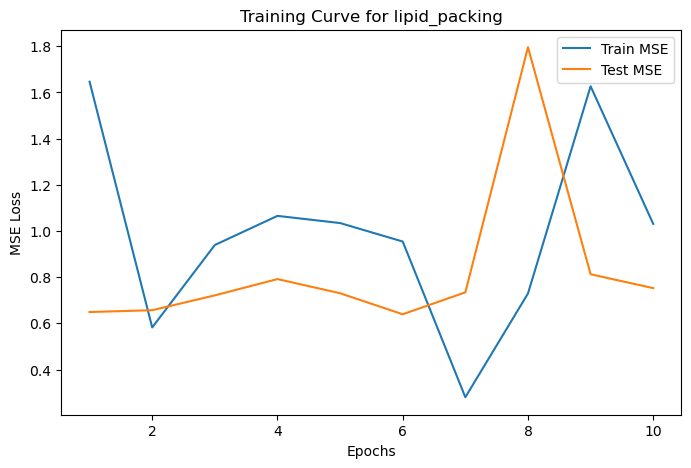

In [17]:
# =========================================
# 5. Evaluation Visualization
# =========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train MSE')
plt.plot(range(1, epochs + 1), test_losses, label='Test MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title(f'Training Curve for {", ".join(target_properties)}')
plt.legend()
plt.savefig(train_res_dir / 'loss_curve.png')
plt.show()

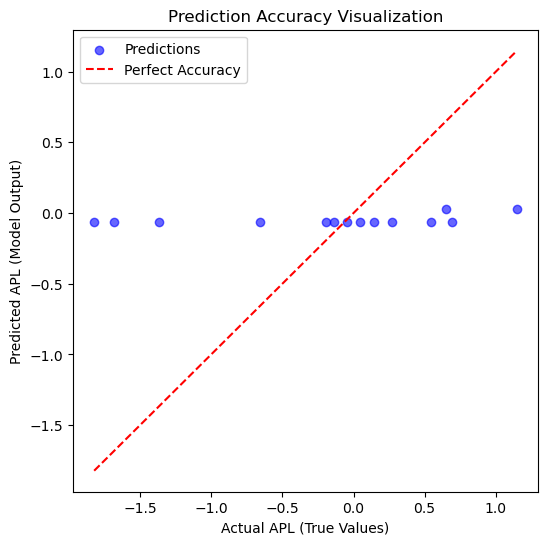

In [18]:
# =========================================
# 6. Scatter Plot Accuracy Visualization
# =========================================
# Create a Scatter Plot of Predicted vs Actual true values for the final epoch!
import matplotlib.pyplot as plt
import torch

model.eval()
actuals = []
predictions_list = []

with torch.no_grad():
    for batch in test_loader:
        edge_attr_dict = batch.edge_attr_dict if hasattr(batch, 'edge_attr_dict') else None
        pred = model(batch.x_dict, batch.edge_index_dict, batch.batch_dict, edge_attr_dict)
        
        # Squeeze dimensions so they can form a 1D list simply
        predictions_list.extend(pred.squeeze().tolist())
        actuals.extend(batch.y.squeeze().tolist())

# Format single lists properly if pulling batch outputs into multi-arrays by accident
if type(actuals[0]) is list:
    actuals = [val[0] for val in actuals]
    predictions_list = [val[0] for val in predictions_list]

plt.figure(figsize=(6, 6))
plt.scatter(actuals, predictions_list, alpha=0.6, color='blue', label='Predictions')

# Plot a perfect y=x diagonal line representing 100% accuracy bounding exactly matching min/max ranges
plt.plot([min(actuals), max(actuals)], [min(actuals), max(actuals)], color='red', linestyle='--', label='Perfect Accuracy')

plt.xlabel('Actual APL (True Values)')
plt.ylabel('Predicted APL (Model Output)')
plt.title('Prediction Accuracy Visualization')
plt.legend()
plt.savefig(train_res_dir / 'accuracy_scatter.png')
plt.show()